In [3]:
# Wahrscheinlichkeitsverteilungen und Scores für p > 2 in DataFrame speichern
import numpy as np
import pandas as pd
from pathlib import Path

from efficient_probit_regression.sampling import (
    calculate_lewis_weights_exact,
    compute_leverage_scores,
    compute_random_evaluations_probabilities_v2,
    to_density,
)

# Datensätze einlesen
%store -r Webspam
%store -r Iris
%store -r KDDCup
%store -r Covertype
%store -r Example2D

# Für p > 4 gibt es keine einfache Kontraktionsgarantie mehr.
p = [2.3, 2.5, 3.0, 3.5, 4.0]
LEWIS_ITERATIONS = 20
RANDOM_M = 1000
RANDOM_SEED = 2026

datasets = {
    "Webspam": Webspam,
    "Iris": Iris,
    "KDDCup": KDDCup,
    "Covertype": Covertype,
    "Example2D": Example2D,
}


def scale_factor_d_p_over_2_minus_1(d: int, p_val: float):
    return float(d ** (p_val / 2.0 - 1.0))


def compute_all_scores_for_p_gt_2(X: np.ndarray, p_val: float, seed=RANDOM_SEED, m_random=RANDOM_M, T=LEWIS_ITERATIONS):
    # Liefert alle Scores und Dichten für einen Datensatz X und einen p-Wert > 2.
    n, d = X.shape
    scale_factor = scale_factor_d_p_over_2_minus_1(d, p_val)

    # 1) l2 leverage score
    l2_scores = compute_leverage_scores(X, p=2.0, fast_approx=False)

    # 2) lp leverage score
    lp_scores = compute_leverage_scores(X, p=p_val, fast_approx=False)

    # 3) Lewis weights
    lewis_weights = calculate_lewis_weights_exact(X, p=p_val, T=T)

    # 4) Random evaluations probabilities
    random_prob = compute_random_evaluations_probabilities_v2(X, m=m_random, p=p_val, rng=seed)

    # 5) Neue p > 2 Kombination: d^(p/2 - 1) * l2 + lp
    l2_lp_scores_scaled = scale_factor * l2_scores + lp_scores

    # 6) Skalierte Lewis-Masse für unnormierte Vergleiche
    lewis_weights_scaled = scale_factor * lewis_weights

    return {
        "n": int(n),
        "d": int(d),
        "scale_factor": float(scale_factor),
        "reference_mass_d": float(d),
        "reference_mass_d_p_half": float(d ** (p_val / 2.0)),
        "score_l2": l2_scores,
        "score_lp": lp_scores,
        "score_lewis_weight": lewis_weights,
        "score_lewis_weight_scaled": lewis_weights_scaled,
        "score_l2_lp_leverage_score_scaled": l2_lp_scores_scaled,
        "prob_lp": to_density(lp_scores),
        "prob_lewis_weight": to_density(lewis_weights),
        "prob_random_evaluations_probabilities": random_prob,
        "prob_l2_lp_leverage_score_scaled": to_density(l2_lp_scores_scaled),
    }


rows = []

for ds_name, ds in datasets.items():
    X = ds.X

    for p_val in p:
        result = compute_all_scores_for_p_gt_2(X, p_val=p_val)

        entry = {
            "dataset": ds_name,
            "p": float(p_val),
        }
        entry.update(result)
        rows.append(entry)

df_probs = pd.DataFrame(rows)

ausgabe_dir = Path("Plots")
ausgabe_dir.mkdir(exist_ok=True)
ausgabe_path = ausgabe_dir / "probability_distributions_p_greater_2.pkl"
df_probs.to_pickle(ausgabe_path)

print("Gespeichert:", ausgabe_path)
print(df_probs[["dataset", "p", "d", "scale_factor"]])


Gespeichert: Plots\probability_distributions_p_greater_2.pkl
      dataset    p    d  scale_factor
0     Webspam  2.3  129      2.072948
1     Webspam  2.5  129      3.370136
2     Webspam  3.0  129     11.357817
3     Webspam  3.5  129     38.277387
4     Webspam  4.0  129    129.000000
5        Iris  2.3    5      1.273050
6        Iris  2.5    5      1.495349
7        Iris  3.0    5      2.236068
8        Iris  3.5    5      3.343702
9        Iris  4.0    5      5.000000
10     KDDCup  2.3   34      1.697156
11     KDDCup  2.5   34      2.414736
12     KDDCup  3.0   34      5.830952
13     KDDCup  3.5   34     14.080212
14     KDDCup  4.0   34     34.000000
15  Covertype  2.3   55      1.824124
16  Covertype  2.5   55      2.723270
17  Covertype  3.0   55      7.416198
18  Covertype  3.5   55     20.196309
19  Covertype  4.0   55     55.000000
20  Example2D  2.3    3      1.179148
21  Example2D  2.5    3      1.316074
22  Example2D  3.0    3      1.732051
23  Example2D  3.5    3    

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from efficient_probit_regression.sampling import to_density
from efficient_probit_regression.total_variation_distance import total_variation_distance

# DataFrame laden
PICKLE_PATH = Path("Plots") / "probability_distributions_p_greater_2.pkl"
df_probs = pd.read_pickle(PICKLE_PATH)

OUT_DIR = Path("Plots") / "BA_Comparison_p_greater_2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

METHODS = [
    ("lp Leverage Scores", "prob_lp"),
    ("Lewis Weights", "prob_lewis_weight"),
    ("Random Evaluations", "prob_random_evaluations_probabilities"),
    ("d^(p/2-1)L2 + Lp", "prob_l2_lp_leverage_score_scaled"),
]


def topk_sorted_cumsum(prob):
    # Sortiert prob absteigend und gibt cumulative sums zurück.
    s = np.sort(to_density(prob))[::-1]
    return np.cumsum(s)


def k_for_mass(cumsum, target):
    # Kleinstes k mit cumsum[k-1] >= target.
    idx = np.searchsorted(cumsum, target, side="left")
    return int(min(idx + 1, len(cumsum)))


def tv_matrix_from_row(row):
    # 4x4 TV-Matrix für eine Zeile (Datensatz,p) über METHODS.
    cols = [m[1] for m in METHODS]
    probs = [to_density(row[c]) for c in cols]
    k = len(probs)
    tv = np.zeros((k, k), dtype=float)
    for i in range(k):
        for j in range(k):
            tv[i, j] = total_variation_distance(probs[i], probs[j])
    return tv


def compute_common_ks(df_probs, num_points=90):
    # Einheitliche k-Stützstellen (x-Achse) für alle Plots.
    n_max = 0
    for _, row in df_probs.iterrows():
        n_max = max(n_max, len(to_density(row[METHODS[0][1]])))

    ks = np.unique(np.round(np.logspace(0, np.log10(n_max), num_points)).astype(int))
    ks = ks[ks >= 1]
    ks = np.unique(np.concatenate([ks, np.array([n_max], dtype=int)]))

    return ks


def plot_topk_mass_curves_with_thresholds(
        row,
        ks,
        thresholds=(0.5, 0.9, 0.95),
        save=False,
        show=True,
        out_dir=OUT_DIR,
        dpi=200,
        annotate_ks=False
):
    # Top-k mass curves + horizontale Schwellenlinien + Marker.
    dataset = row["dataset"]
    p_val = row["p"]

    fig, ax = plt.subplots(figsize=(9, 5))
    summary = []

    for label, col in METHODS:
        c = topk_sorted_cumsum(row[col])
        n = len(c)
        ks_eff = ks[ks <= n]

        if len(ks_eff) == 0 or ks_eff[-1] != n:
            ks_eff = np.unique(np.concatenate([ks_eff, np.array([n], dtype=int)]))
        y = c[ks_eff - 1]

        ax.plot(ks_eff, y, linewidth=1.8, label=label)

        entry = {"dataset": dataset, "p": float(p_val), "method": label}
        for t in thresholds:
            entry[f"k{int(t * 100)}"] = k_for_mass(c, t)

        summary.append(entry)

        for t in thresholds:
            k_t = entry[f"k{int(t * 100)}"]
            y_t = c[k_t - 1]
            ax.scatter([k_t], [y_t], s=22)
            if annotate_ks:
                ax.text(k_t, y_t, f"  k={k_t}", va="center", fontsize=9)

    for t in thresholds:
        ax.axhline(t, linestyle="--", linewidth=1.0, alpha=0.7)

    ax.set_xscale("log")
    ax.set_ylim(0, 1.01)
    ax.set_title(f"{dataset} (p = {p_val})\nTop-$k$-Kurve")
    ax.set_xlabel("$k$ (log)")
    ax.set_ylabel(r"$M(k)$")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=10)
    ax.set_ylim(0.0, 1.02)
    ax.set_yticks([0.0, 0.5, 0.9, 1.0])
    ax.set_yticklabels(["0", "0.5", "0.9", "1.0"])

    fig.tight_layout()

    if save:
        p_str = str(p_val).replace(".", "_")
        out_path = out_dir / f"TopK_{dataset}_p_{p_str}.png"
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        print("Gespeichert:", out_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return pd.DataFrame(summary)


def generate_all_topk_plots_and_table(
        df_probs,
        save=True,
        show=False,
        thresholds=(0.5, 0.9, 0.95),
        num_points=90,
        annotate_ks=False,
        save_table=True,
        out_dir=OUT_DIR
):
    # Pro Datensatz und p Top-k Plot erzeugen + k50/k90/k95 Tabelle sammeln.
    ks = compute_common_ks(df_probs, num_points=num_points)
    all_summaries = []

    for dataset_name in df_probs["dataset"].unique():
        sub = df_probs[df_probs["dataset"] == dataset_name].sort_values("p")
        for _, row in sub.iterrows():
            df_sum = plot_topk_mass_curves_with_thresholds(
                row, ks=ks, thresholds=thresholds,
                save=save, show=show, annotate_ks=annotate_ks,
                out_dir=out_dir
            )
            all_summaries.append(df_sum)

    summary_df = pd.concat(all_summaries, ignore_index=True)

    if save_table:
        out_csv = out_dir / "TopK_thresholds_table_p_greater_2.csv"
        summary_df.to_csv(out_csv, index=False)
        print("Tabelle gespeichert:", out_csv)

    return summary_df


def compute_global_tv_vmax(df_probs, robust=False, quantile=0.95):
    # Bestimmt vmax für konsistente TVD-Skala.
    vals = []
    for _, row in df_probs.iterrows():
        tv = tv_matrix_from_row(row)
        off = tv[~np.eye(tv.shape[0], dtype=bool)]
        vals.append(off)
    vals = np.concatenate(vals)

    if robust:
        return float(np.quantile(vals, quantile))
    return float(np.max(vals))


def plot_tv_heatmap(
        row,
        vmin=0.0,
        vmax=1.0,
        save=False,
        show=True,
        out_dir=OUT_DIR,
        dpi=200,
        annotate=True
):
    # 4x4 TV Heatmap (eine pro Datensatz,p) mit fixer Skala.
    dataset = row["dataset"]
    p_val = row["p"]

    labels = [m[0] for m in METHODS]
    tv = tv_matrix_from_row(row)
    k = tv.shape[0]

    fig, ax = plt.subplots(figsize=(7.3, 6.2))
    im = ax.imshow(tv, aspect="equal", vmin=vmin, vmax=vmax)

    ax.set_title(f"{dataset} (p = {p_val})\nTVD")
    ax.set_xticks(range(k))
    ax.set_yticks(range(k))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("TVD")

    if annotate:
        for i in range(k):
            for j in range(k):
                ax.text(j, i, f"{tv[i, j]:.3f}", ha="center", va="center")

    ax.set_xlabel("Methode")
    ax.set_ylabel("Methode")
    fig.tight_layout()

    if save:
        p_str = str(p_val).replace(".", "_")
        out_path = out_dir / f"TVD_Heatmap_{dataset}_p_{p_str}.png"
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        print("Gespeichert:", out_path)

    if show:
        plt.show()
    else:
        plt.close(fig)


def generate_all_tv_heatmaps(
        df_probs,
        save=True,
        show=False,
        robust_vmax=False,
        quantile=0.95,
        annotate=True,
        out_dir=OUT_DIR
):
    # Pro Datensatz und p TV Heatmap erzeugen, alle mit gleicher Skala.
    vmax = compute_global_tv_vmax(df_probs, robust=robust_vmax, quantile=quantile)
    vmin = 0.0
    print(f"TV Heatmap scale fixed: vmin={vmin}, vmax={vmax:.4f} "
          f"{'(robust)' if robust_vmax else '(global max)'}")

    for dataset_name in df_probs["dataset"].unique():
        sub = df_probs[df_probs["dataset"] == dataset_name].sort_values("p")
        for _, row in sub.iterrows():
            plot_tv_heatmap(
                row, vmin=vmin, vmax=vmax,
                save=save, show=show, annotate=annotate,
                out_dir=out_dir
            )


def plot_compact_topk_figure_for_dataset(
        df_probs,
        dataset_name,
        p_values=None,
        thresholds=(0.5, 0.9),
        num_points=90,
        save=False,
        show=True,
        out_dir=OUT_DIR,
        dpi=300,
):
    if p_values is None:
        p_values = sorted(df_probs[df_probs["dataset"] == dataset_name]["p"].unique().tolist())

    ks = compute_common_ks(df_probs, num_points=num_points)

    sub = df_probs[df_probs["dataset"] == dataset_name].copy()
    sub = sub[sub["p"].isin(p_values)].sort_values("p")

    n_panels = len(p_values)
    nrows, ncols = 1, n_panels
    figsize = (3.6 * n_panels, 3.2)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    if n_panels == 1:
        axes = [axes]
    else:
        axes = axes.ravel()

    global_handles = None
    global_labels = None

    for idx, (_, row) in enumerate(sub.iterrows()):
        ax = axes[idx]
        p_val = row["p"]

        handles = []
        labels = []

        for label, col in METHODS:
            c = topk_sorted_cumsum(row[col])
            n = len(c)

            ks_eff = ks[ks <= n]

            if len(ks_eff) == 0 or ks_eff[-1] != n:
                ks_eff = np.unique(np.concatenate([ks_eff, np.array([n], dtype=int)]))

            y = c[ks_eff - 1]
            h, = ax.plot(ks_eff, y, linewidth=1.8, label=label)
            handles.append(h)
            labels.append(label)

        for t in thresholds:
            ax.axhline(t, linestyle="--", linewidth=1.0, alpha=0.45)

        ax.set_xscale("log")
        ax.set_title(f"p = {p_val}", fontsize=14)
        ax.grid(True, which="major", linestyle="--", alpha=0.25)
        ax.grid(False, which="minor")
        ax.minorticks_off()
        ax.set_ylim(0.0, 1.02)
        ax.set_yticks([0.0, 0.5, 0.9, 1.0])
        ax.tick_params(labelleft=(idx == 0))

        if global_handles is None:
            global_handles = handles
            global_labels = labels

    axes[0].set_ylabel(r"$M(k)$", fontsize=16)
    for ax in axes:
        ax.set_xlabel("k (log)", fontsize=16)

    fig.suptitle(f"{dataset_name}", fontsize=20, y=0.98)
    fig.legend(
        global_handles, global_labels,
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.9),
        fontsize=14
    )

    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.92])

    if save:
        out_path = out_dir / f"CompactTopK_{dataset_name}_p_greater_2.png"
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        print("Gespeichert:", out_path)

    if show:
        plt.show()
    else:
        plt.close(fig)


def generate_compact_figures_all_datasets(
        df_probs,
        save=True,
        show=False,
        thresholds=(0.5, 0.9),
        num_points=90,
        out_dir=OUT_DIR
):
    for dataset_name in df_probs["dataset"].unique():
        p_values = sorted(df_probs[df_probs["dataset"] == dataset_name]["p"].unique().tolist())
        plot_compact_topk_figure_for_dataset(
            df_probs,
            dataset_name=dataset_name,
            p_values=p_values,
            thresholds=thresholds,
            num_points=num_points,
            save=save,
            show=show,
            out_dir=out_dir
        )

# Top-k Plots + Tabelle
summary_df = generate_all_topk_plots_and_table(df_probs, save=True, show=False, annotate_ks=False)

# Kompakte BA-Figuren (pro Datensatz 1 Figure mit 5 Panels)
generate_compact_figures_all_datasets(df_probs, save=True, show=False, thresholds=(0.5, 0.9))

# TV Heatmaps (einheitliche Skala)
generate_all_tv_heatmaps(df_probs, save=True, show=False, robust_vmax=True, quantile=0.95, annotate=True)


Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_Webspam_p_2_3.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_Webspam_p_2_5.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_Webspam_p_3_0.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_Webspam_p_3_5.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_Webspam_p_4_0.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_Iris_p_2_3.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_Iris_p_2_5.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_Iris_p_3_0.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_Iris_p_3_5.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_Iris_p_4_0.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_KDDCup_p_2_3.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_KDDCup_p_2_5.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_KDDCup_p_3_0.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_KDDCup_p_3_5.png
Gespeichert: Plots\BA_Comparison_p_greater_2\TopK_KDDCup_p_4_0.png


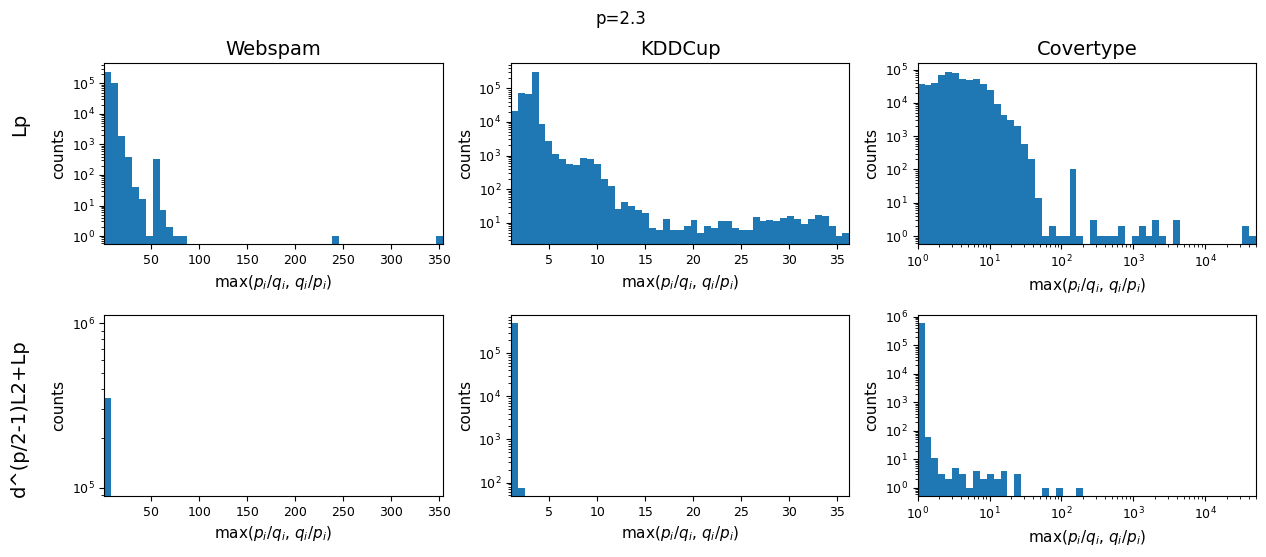

Saved: Plots\Distribution_Comparison_p_greater_2\comparison_distributions_p_2_3.png


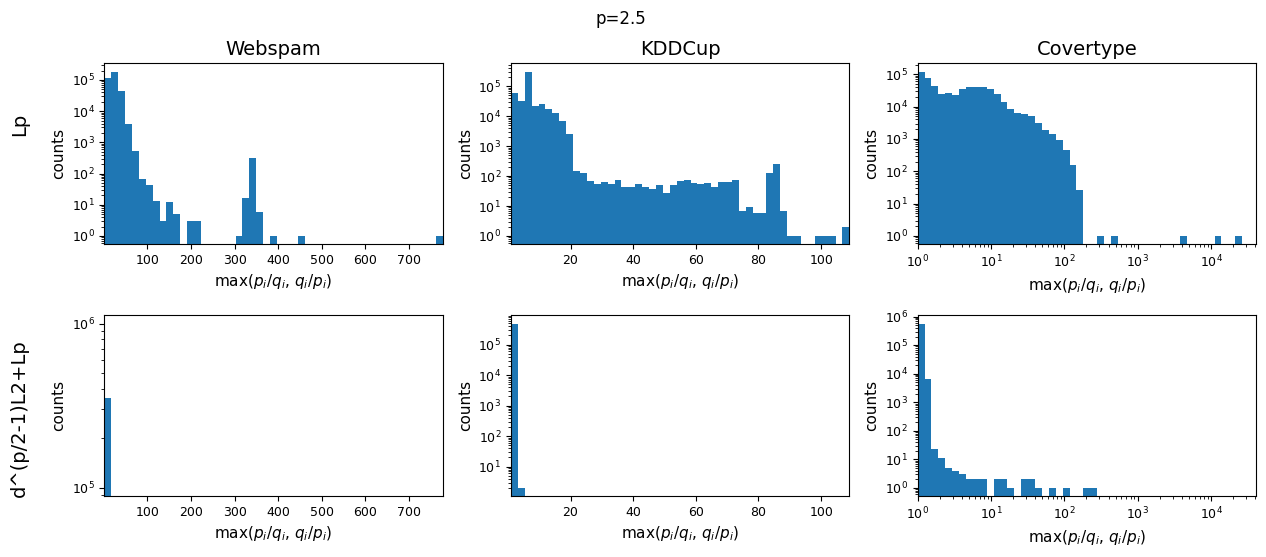

Saved: Plots\Distribution_Comparison_p_greater_2\comparison_distributions_p_2_5.png


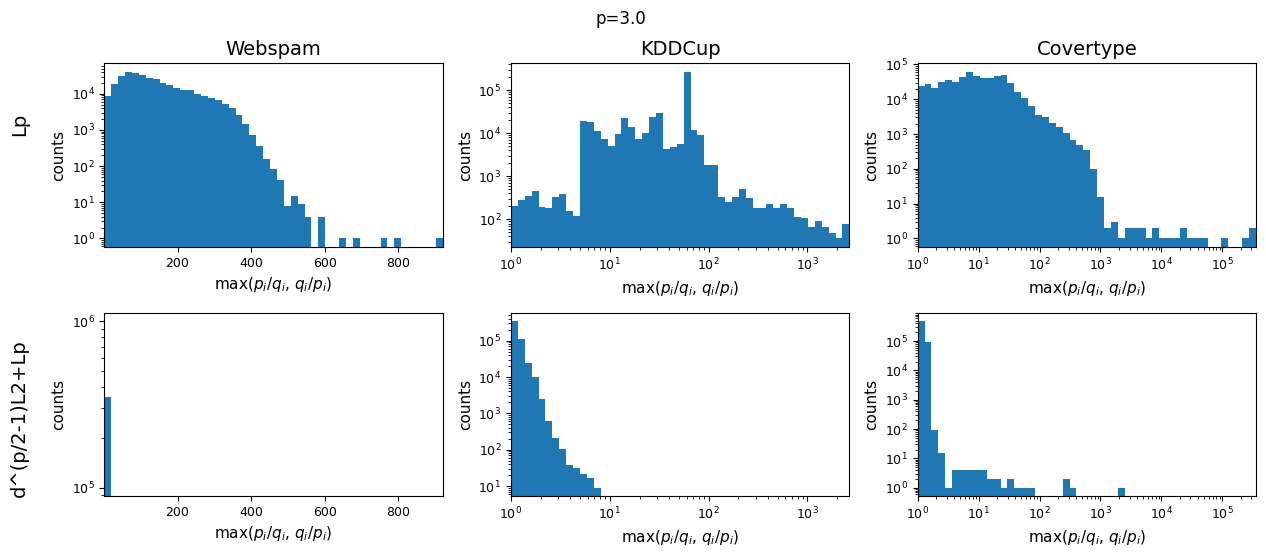

Saved: Plots\Distribution_Comparison_p_greater_2\comparison_distributions_p_3_0.png


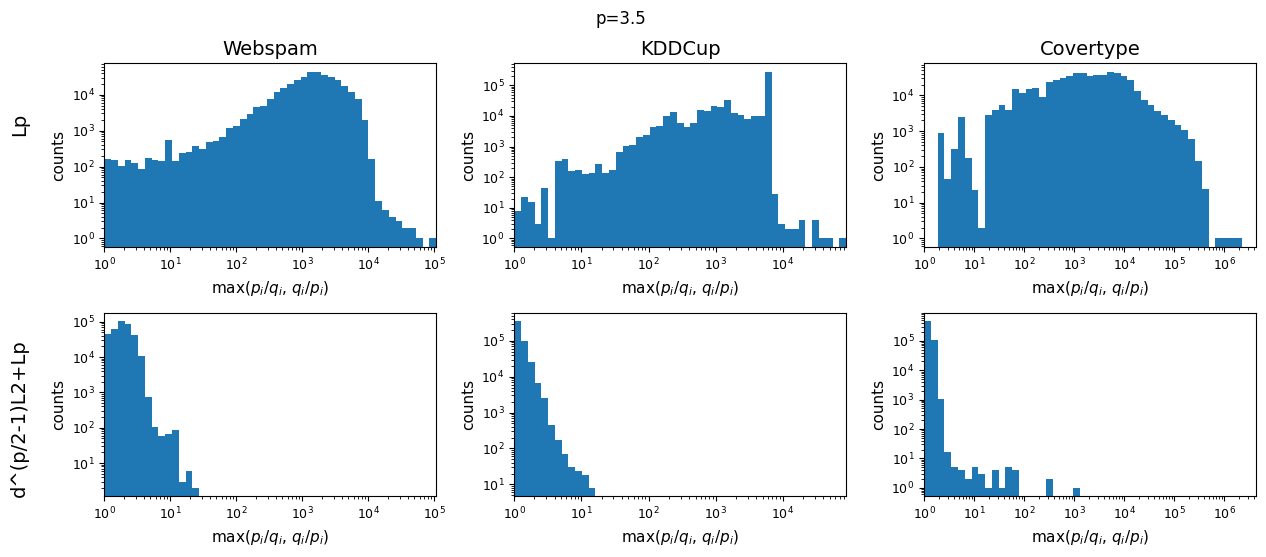

Saved: Plots\Distribution_Comparison_p_greater_2\comparison_distributions_p_3_5.png


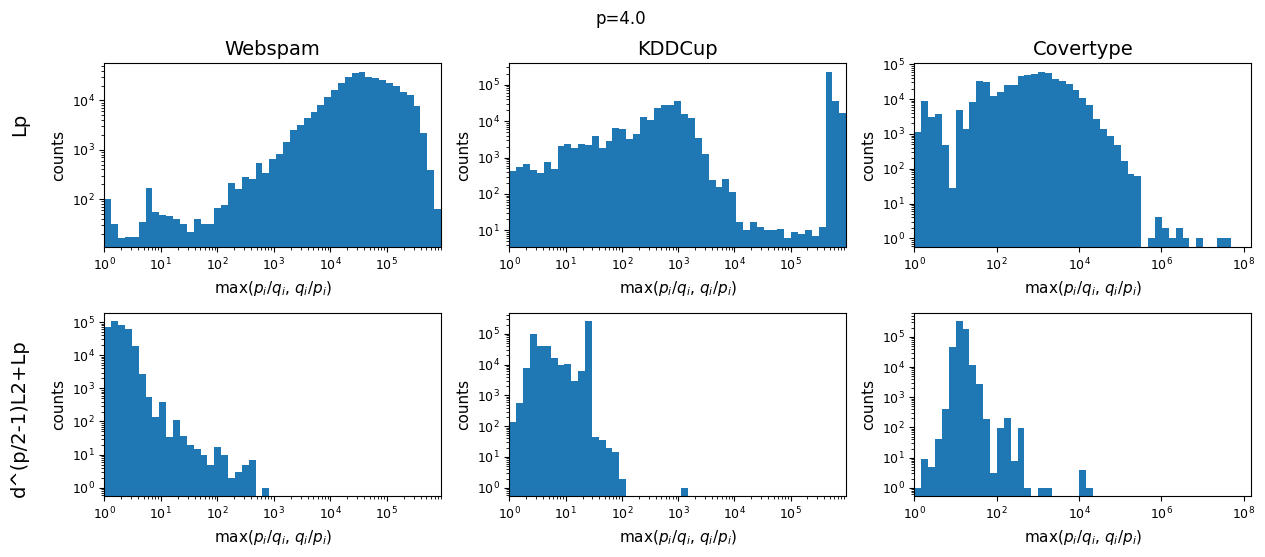

Saved: Plots\Distribution_Comparison_p_greater_2\comparison_distributions_p_4_0.png


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# DataFrame laden
PICKLE_PATH = Path("Plots") / "probability_distributions_p_greater_2.pkl"
df_probs = pd.read_pickle(PICKLE_PATH)

OUT_DIR = Path("Plots") / "Distribution_Comparison_p_greater_2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

plot_datasets = ["Webspam", "KDDCup", "Covertype"]
EPS = 1e-300


def choose_bins_and_xscale(r, n_bins=50):
    r = r[np.isfinite(r)]
    rmax = float(np.max(r)) if r.size else 1.0
    rmax = max(rmax, 1.0000001)

    if rmax > 1e3:
        bins = np.logspace(0, np.log10(rmax), n_bins)
        xscale = "log"
    else:
        if rmax % 2 == 1:
            n_bins += 1
        bins = np.linspace(1.0, rmax, n_bins)
        xscale = "linear"
    return bins, xscale


for p_param in sorted(df_probs["p"].unique()):
    fig, axes = plt.subplots(2, len(plot_datasets), figsize=(13, 6))

    for col, ds_title in enumerate(plot_datasets):
        row = df_probs[(df_probs["dataset"] == ds_title) & (df_probs["p"] == p_param)].iloc[0]

        # q = Lewis weights -> density
        q = row["prob_lewis_weight"]

        # p1 = lp leverage -> density
        p1 = row["prob_lp"]

        # p2 = d^(p/2 - 1) * l2 + lp -> density
        p2 = row["prob_l2_lp_leverage_score_scaled"]

        # Ratios
        r_lp = np.maximum(p1 / np.maximum(q, EPS), q / np.maximum(p1, EPS))
        r_l2lp_scaled = np.maximum(p2 / np.maximum(q, EPS), q / np.maximum(p2, EPS))

        # Gemeinsame x-Skala für obere und untere Grafik
        rmax_common = max(float(np.max(r_lp)), float(np.max(r_l2lp_scaled)))
        rmax_common = max(rmax_common, 1.2)
        bins_common, xscale_common = choose_bins_and_xscale(np.array([1.0, rmax_common]), n_bins=50)

        # Row 0: lp vs lewis
        ax = axes[0, col]
        ax.hist(r_lp, bins=bins_common)
        ax.set_yscale("log")
        ax.set_xscale(xscale_common)
        ax.set_xlim(1, rmax_common)
        ax.set_title(ds_title)
        ax.set_xlabel(r"max($p_i/q_i$, $q_i/p_i$)")
        ax.set_ylabel("counts")

        # Row 1: d^(p/2-1)L2+Lp vs lewis
        ax = axes[1, col]
        ax.hist(r_l2lp_scaled, bins=bins_common)
        ax.set_yscale("log")
        ax.set_xscale(xscale_common)
        ax.set_xlim(1, rmax_common)
        ax.set_xlabel(r"max($p_i/q_i$, $q_i/p_i$)")
        ax.set_ylabel("counts")

    fig.text(0.03, 0.73, "Lp", rotation=90, va="center", fontsize=14)
    fig.text(0.03, 0.24, "d^(p/2-1)L2+Lp", rotation=90, va="center", fontsize=14)

    fig.suptitle(f"p={p_param}", y=0.92)
    fig.tight_layout(rect=[0.05, 0.0, 1.0, 0.95])

    p_str = str(p_param).replace(".", "_")
    out_path = OUT_DIR / f"comparison_distributions_p_{p_str}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved:", out_path)


Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Covertype_p_2_3.png
Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Covertype_p_2_5.png
Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Covertype_p_3_0.png
Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Covertype_p_3_5.png
Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Covertype_p_4_0.png
Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Example2D_p_2_3.png
Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Example2D_p_2_5.png
Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Example2D_p_3_0.png
Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Example2D_p_3_5.png
Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Example2D_p_4_0.png
Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Iris_p_2_3.png
Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\ratio_hist_Iris_p_2_5.png
Gespeichert: P

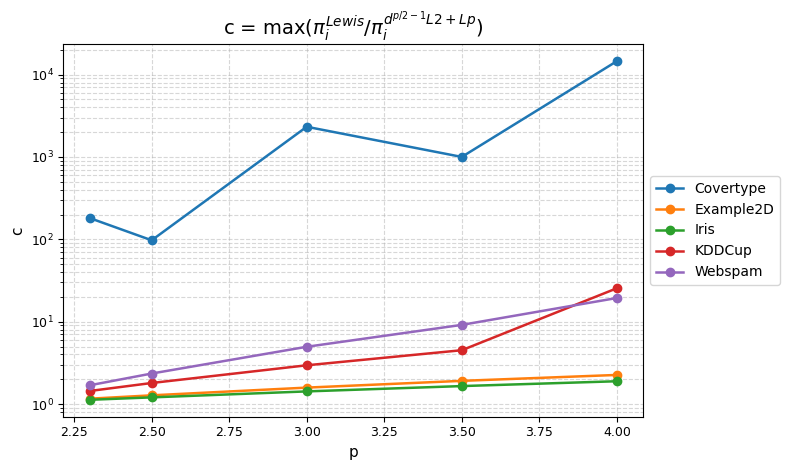

Gespeichert: Plots\Lewis_vs_scaled_l2lp_p_greater_2\c_values_p_greater_2.png


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PICKLE_PATH = Path("Plots") / "probability_distributions_p_greater_2.pkl"
df_probs = pd.read_pickle(PICKLE_PATH)

OUT_DIR = Path("Plots") / "Lewis_vs_scaled_l2lp_p_greater_2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path("Tabellen")
TABLE_DIR.mkdir(exist_ok=True)

plt.style.use("default")
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 10

EPS = 1e-300


def choose_ratio_bins(ratio, n_bins=60):
    ratio = np.asarray(ratio, dtype=float)
    ratio = ratio[np.isfinite(ratio)]
    ratio = ratio[ratio > 0]

    rmin = float(max(np.min(ratio), 1e-6))
    rmax = float(max(np.max(ratio), rmin * 1.01))

    if rmax / rmin > 50:
        bins = np.logspace(np.log10(rmin), np.log10(rmax), n_bins)
        xscale = "log"
    else:
        bins = np.linspace(rmin, rmax, n_bins)
        xscale = "linear"

    # Include the true maximum safely in the last bin despite floating-point rounding.
    bins[-1] = np.nextafter(rmax, np.inf)

    return bins, xscale


rows_c = []

for _, row in df_probs.sort_values(["dataset", "p"]).iterrows():
    dataset_name = row["dataset"]
    p_val = float(row["p"])
    p_str = str(p_val).replace(".", "_")

    ratio = np.maximum(row["prob_lewis_weight"], EPS) / np.maximum(row["prob_l2_lp_leverage_score_scaled"], EPS)
    ratio = ratio[np.isfinite(ratio)]

    c_value = float(np.max(ratio))
    rows_c.append({
        "dataset": dataset_name,
        "p": p_val,
        "d": int(row["d"]),
        "scale_factor": float(row["scale_factor"]),
        "c": c_value,
        "ratio_mean": float(np.mean(ratio)),
        "ratio_median": float(np.median(ratio)),
    })

    bins, xscale = choose_ratio_bins(ratio, n_bins=60)

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.hist(ratio, bins=bins)
    ax.set_xscale(xscale)
    ax.set_yscale("log")
    ax.axvline(c_value, color="tab:red", linestyle="--", linewidth=1.3, label=f"c = {c_value:.3f}")
    ax.set_title(f"{dataset_name} (p = {p_val})")
    ax.set_xlabel(r"$\pi^{Lewis}_i / \pi^{d^{p/2-1}L2+Lp}_i$")
    ax.set_ylabel("counts")
    ax.legend(loc="upper right")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    fig.tight_layout()

    out_path = OUT_DIR / f"ratio_hist_{dataset_name}_p_{p_str}.png"
    fig.savefig(out_path, dpi=250, bbox_inches="tight")
    plt.close(fig)
    print("Gespeichert:", out_path)


df_c = pd.DataFrame(rows_c).sort_values(["dataset", "p"]).reset_index(drop=True)
df_c[["scale_factor", "c", "ratio_mean", "ratio_median"]] = df_c[["scale_factor", "c", "ratio_mean", "ratio_median"]].round(4)
df_c_export = df_c[["dataset", "p", "d", "scale_factor", "c"]].copy()

out_csv = TABLE_DIR / "Bestimmung_c_max_p_groesser_2.csv"
df_c_export.to_csv(out_csv, index=False)
print("CSV gespeichert:", out_csv)

out_stats_csv = TABLE_DIR / "Bestimmung_c_max_statistik_p_groesser_2.csv"
df_c.to_csv(out_stats_csv, index=False)
print("CSV gespeichert:", out_stats_csv)
print(df_c_export)

fig, ax = plt.subplots(figsize=(8.0, 4.8))
for dataset_name in df_c["dataset"].unique():
    sub = df_c[df_c["dataset"] == dataset_name].sort_values("p")
    ax.plot(sub["p"], sub["c"], marker="o", linewidth=1.8, label=dataset_name)

ax.set_title(r"c = max($\pi^{Lewis}_i / \pi^{d^{p/2-1}L2+Lp}_i$)")
ax.set_xlabel("p")
ax.set_ylabel("c")
ax.set_yscale("log")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()

out_path = OUT_DIR / "c_values_p_greater_2.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Gespeichert:", out_path)

# pi entspricht die normierte Samplingverteilung

CSV gespeichert: Tabellen\Score_Massen_p_groesser_2.csv
      dataset    p    d  scale_factor     sum_lewis  sum_scaled_lewis  \
0   Covertype  2.3   55        1.8241  5.570150e+01      1.016064e+02   
1   Covertype  2.5   55        2.7233  5.577570e+01      1.518923e+02   
2   Covertype  3.0   55        7.4162  5.937400e+01      4.403290e+02   
3   Covertype  3.5   55       20.1963  5.974840e+01      1.206697e+03   
4   Covertype  4.0   55       55.0000  3.499796e+06      1.924888e+08   
5   Example2D  2.3    3        1.1791  3.000000e+00      3.537400e+00   
6   Example2D  2.5    3        1.3161  3.000000e+00      3.948200e+00   
7   Example2D  3.0    3        1.7321  3.000000e+00      5.196200e+00   
8   Example2D  3.5    3        2.2795  3.035600e+00      6.919700e+00   
9   Example2D  4.0    3        3.0000  1.190125e+02      3.570375e+02   
10       Iris  2.3    5        1.2731  5.000000e+00      6.365300e+00   
11       Iris  2.5    5        1.4953  5.000000e+00      7.476700e+0

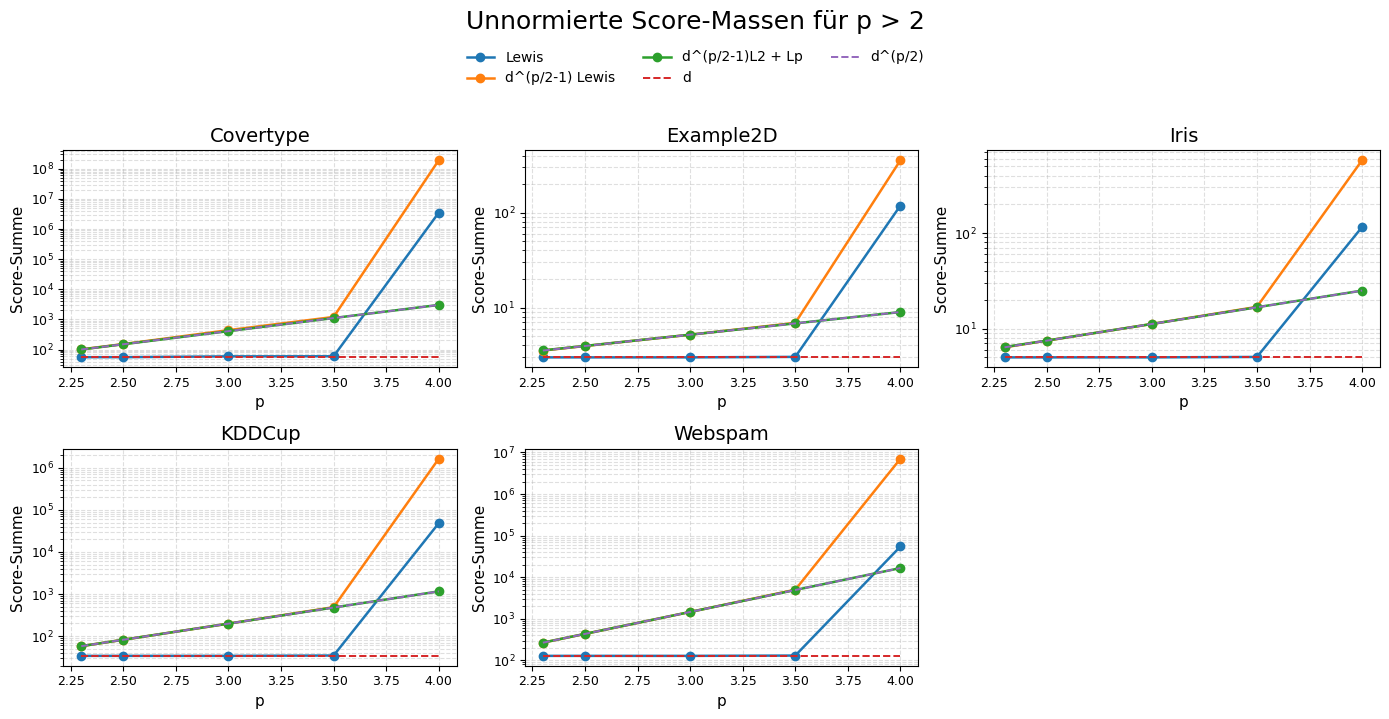

Gespeichert: Plots\Raw_Score_Comparison_p_greater_2\Score_Massen_p_groesser_2.png


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PICKLE_PATH = Path("Plots") / "probability_distributions_p_greater_2.pkl"
df_probs = pd.read_pickle(PICKLE_PATH)

OUT_DIR = Path("Plots") / "Raw_Score_Comparison_p_greater_2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path("Tabellen")
TABLE_DIR.mkdir(exist_ok=True)

plt.style.use("default")
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 10

rows_mass = []
for _, row in df_probs.iterrows():
    rows_mass.append({
        "dataset": row["dataset"],
        "p": float(row["p"]),
        "d": int(row["d"]),
        "scale_factor": float(row["scale_factor"]),
        "sum_lewis": float(np.sum(row["score_lewis_weight"])),
        "sum_scaled_lewis": float(np.sum(row["score_lewis_weight_scaled"])),
        "sum_scaled_l2lp": float(np.sum(row["score_l2_lp_leverage_score_scaled"])),
        "reference_d": float(row["reference_mass_d"]),
        "reference_d_p_half": float(row["reference_mass_d_p_half"]),
    })

df_mass = pd.DataFrame(rows_mass).sort_values(["dataset", "p"]).reset_index(drop=True)
df_mass[["scale_factor", "sum_lewis", "sum_scaled_lewis", "sum_scaled_l2lp", "reference_d", "reference_d_p_half"]] = df_mass[["scale_factor", "sum_lewis", "sum_scaled_lewis", "sum_scaled_l2lp", "reference_d", "reference_d_p_half"]].round(4)

out_csv = TABLE_DIR / "Score_Massen_p_groesser_2.csv"
df_mass.to_csv(out_csv, index=False)
print("CSV gespeichert:", out_csv)
print(df_mass)

datasets = df_mass["dataset"].unique().tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
axes = axes.ravel()

for idx, dataset_name in enumerate(datasets):
    ax = axes[idx]
    sub = df_mass[df_mass["dataset"] == dataset_name].sort_values("p")

    ax.plot(sub["p"], sub["sum_lewis"], marker="o", linewidth=1.8, label="Lewis")
    ax.plot(sub["p"], sub["sum_scaled_lewis"], marker="o", linewidth=1.8, label="d^(p/2-1) Lewis")
    ax.plot(sub["p"], sub["sum_scaled_l2lp"], marker="o", linewidth=1.8, label="d^(p/2-1)L2 + Lp")
    ax.plot(sub["p"], sub["reference_d"], linestyle="--", linewidth=1.4, label="d")
    ax.plot(sub["p"], sub["reference_d_p_half"], linestyle="--", linewidth=1.4, label="d^(p/2)")

    ax.set_title(dataset_name)
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.set_xlabel("p")
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_ylabel("Score-Summe")

for ax in axes[len(datasets):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.98))
fig.suptitle("Unnormierte Score-Massen für p > 2", fontsize=18, y=1.02)
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.93])

out_path = OUT_DIR / "Score_Massen_p_groesser_2.png"
fig.savefig(out_path, dpi=250, bbox_inches="tight")
plt.show()

print("Gespeichert:", out_path)
